# Modelling: Phase  1

## Step 1: All Imports

In [ ]:
# All imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

#  Data
data = yf.download('^GSPC', start='2000-01-01', end='2024-12-31')
df   = data.copy()

# Feature Engineering
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

def compute_rsi(series, window=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0).rolling(window).mean()
    loss     = (-delta.clip(upper=0)).rolling(window).mean()
    return 100 - (100 / (1 + gain / (loss + 1e-10)))

df['RSI']         = compute_rsi(df['Close'])
ema12             = df['Close'].ewm(span=12, adjust=False).mean()
ema26             = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD']        = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['EMA_20']      = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_50']      = df['Close'].ewm(span=50, adjust=False).mean()
df['SMA_20']      = df['Close'].rolling(20).mean()
df['SMA_50']      = df['Close'].rolling(50).mean()
df['Volatility']  = df['Log_Return'].rolling(20).std()
df.dropna(inplace=True)

# ── Target & Features ──
feature_cols = ['Open','High','Low','Close','Volume',
                'Log_Return','RSI','MACD','MACD_Signal',
                'EMA_20','EMA_50','SMA_20','SMA_50','Volatility']
df['Target'] = df['Log_Return'].shift(-1)
df.dropna(inplace=True)

features = df[feature_cols].values
target   = df['Target'].values

# Split
n          = len(features)
train_end  = int(n * 0.70)
val_end    = int(n * 0.85)

scaler         = MinMaxScaler()
X_train_scaled = scaler.fit_transform(features[:train_end])
X_val_scaled   = scaler.transform(features[train_end:val_end])
X_test_scaled  = scaler.transform(features[val_end:])
y_train, y_val, y_test = target[:train_end], target[train_end:val_end], target[val_end:]

# Sequences
WINDOW = 30
def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X_tr, y_tr = create_sequences(X_train_scaled, y_train, WINDOW)
X_vl, y_vl = create_sequences(X_val_scaled,   y_val,   WINDOW)
X_te, y_te = create_sequences(X_test_scaled,  y_test,  WINDOW)

def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1))

X_tr_t, y_tr_t = to_tensor(X_tr, y_tr)
X_vl_t, y_vl_t = to_tensor(X_vl, y_vl)
X_te_t, y_te_t = to_tensor(X_te, y_te)

BATCH        = 64
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH, shuffle=False)
val_loader   = DataLoader(TensorDataset(X_vl_t, y_vl_t), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=BATCH, shuffle=False)

INPUT_SIZE = X_tr_t.shape[2]
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Setup complete | Device: {device} | Input features: {INPUT_SIZE}')
print(f'Train: {X_tr.shape} | Val: {X_vl.shape} | Test: {X_te.shape}')

[*********************100%***********************]  1 of 1 completed


Setup complete | Device: cpu | Input features: 14
Train: (4336, 30, 14) | Val: (906, 30, 14) | Test: (906, 30, 14)


## Step 2: Model Definitions

In [ ]:

#  MODEL A: Proposed — CNN + BiLSTM + Attention
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        scores  = self.attn(x)                   # (batch, T, 1)
        weights = torch.softmax(scores, dim=1)
        context = (weights * x).sum(dim=1)       # (batch, hidden_dim)
        return context, weights


class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, input_size, cnn_out=64, lstm_hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64,     kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64,         128,    kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(128,        cnn_out,kernel_size=3, padding=1), nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.bilstm = nn.LSTM(cnn_out, lstm_hidden, num_layers,
                              batch_first=True, bidirectional=True, dropout=dropout)
        self.attention = SelfAttention(lstm_hidden * 2)
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)           # (B, features, T) for Conv1d
        x = self.cnn(x)
        x = x.permute(0, 2, 1)           # (B, T, cnn_out) for LSTM
        lstm_out, _ = self.bilstm(x)
        context, attn_w = self.attention(lstm_out)
        return self.fc(context), attn_w


#  MODEL B: Baseline — Standalone LSTM

class BaselineLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]), None   # last time step only


print('Model classes defined!')

Model classes defined!


## Step 3: Fixed Loss Functions

In [ ]:

class RiskAwareLoss(nn.Module):

    def __init__(self, alpha=0.7, beta=0.2, gamma=0.1):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma

    def forward(self, pred, actual):
        # Component 1: MSE
        mse_loss = torch.mean((pred - actual) ** 2)

        # Component 2: Soft Directional Loss
        soft_dir_loss = torch.mean(torch.relu(-pred * actual))

        # Component 3: Downside Penalty

        downside_mask    = (actual < 0).float()
        downside_penalty = torch.mean(((pred - actual) ** 2) * downside_mask)

        total = (self.alpha * mse_loss +
                 self.beta  * soft_dir_loss +
                 self.gamma * downside_penalty)
        return total


# Standard MSE Loss for baseline model comparison
mse_criterion = nn.MSELoss()

print('Loss functions ready!')
print('RiskAwareLoss weights: alpha=0.7 (MSE), beta=0.2 (Direction), gamma=0.1 (Downside)')

Loss functions ready!
RiskAwareLoss weights: alpha=0.7 (MSE), beta=0.2 (Direction), gamma=0.1 (Downside)


## Step 4: Generic Train Function (reused for both models)

In [ ]:
def train_model(model, criterion, train_loader, val_loader,
                epochs=80, patience=15, lr=5e-4, clip_grad=1.0,
                model_name='model'):

    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # Reduce LR by half if val loss doesn't improve for 8 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8
    )

    best_val_loss   = float('inf')
    patience_count  = 0
    train_losses, val_losses = [], []
    save_path = f'best_{model_name}.pth'

    print(f'\nTraining: {model_name}')
    print('-' * 60)

    for epoch in range(1, epochs + 1):

        #Train phase
        model.train()
        train_loss = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds, _ = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            # Gradient clipping — prevents instability in deep RNNs
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds, _ = model(X_b)
                val_loss += criterion(preds, y_b).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)   # adjust LR if stalled
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 10 == 0:
            cur_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch {epoch:3d}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {cur_lr:.6f}')

        # ── Early stopping ──
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'Early stopping at epoch {epoch} (best val: {best_val_loss:.6f})')
                break

    # Load best weights
    model.load_state_dict(torch.load(save_path))
    return model, train_losses, val_losses


print('Train function defined!')

Train function defined!


## Step 5: Evaluation Function

In [ ]:
def evaluate_model(model, test_loader, model_name='Model'):

    model.eval()
    preds_list, actual_list = [], []

    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds, _ = model(X_b.to(device))
            preds_list.extend(preds.cpu().numpy().flatten())
            actual_list.extend(y_b.numpy().flatten())

    preds   = np.array(preds_list)
    actuals = np.array(actual_list)

    # Statistical Metrics
    rmse    = np.sqrt(mean_squared_error(actuals, preds))
    mae     = mean_absolute_error(actuals, preds)
    dir_acc = np.mean(np.sign(preds) == np.sign(actuals)) * 100

    # Financial Metrics (long when pred > 0, flat when pred < 0)
    position     = np.sign(preds)
    strategy_ret = position * actuals

    sharpe   = (strategy_ret.mean() / (strategy_ret.std() + 1e-10)) * np.sqrt(252)

    neg_rets = strategy_ret[strategy_ret < 0]
    sortino  = (strategy_ret.mean() / (neg_rets.std() + 1e-10)) * np.sqrt(252)

    cum_ret     = np.cumsum(strategy_ret)
    running_max = np.maximum.accumulate(cum_ret)
    max_dd      = (cum_ret - running_max).min() * 100

    results = {
        'model':    model_name,
        'RMSE':     round(rmse, 6),
        'MAE':      round(mae, 6),
        'Dir_Acc':  round(dir_acc, 2),
        'Sharpe':   round(sharpe, 4),
        'Sortino':  round(sortino, 4),
        'Max_DD':   round(max_dd, 2),
        'preds':    preds,
        'actuals':  actuals,
        'strategy_ret': strategy_ret
    }

    print(f'\n{"═"*45}')
    print(f'  RESULTS: {model_name}')
    print(f'{"═"*45}')
    print(f'  RMSE                : {rmse:.6f}')
    print(f'  MAE                 : {mae:.6f}')
    print(f'  Directional Accuracy: {dir_acc:.2f}%')
    print(f'  Sharpe Ratio        : {sharpe:.4f}')
    print(f'  Sortino Ratio       : {sortino:.4f}')
    print(f'  Max Drawdown        : {max_dd:.2f}%')

    return results


print('Evaluation function defined!')

Evaluation function defined!


## Step 6: Train Baseline LSTM (with MSE loss)

In [ ]:
baseline_model = BaselineLSTM(input_size=INPUT_SIZE)

baseline_model, bl_train_loss, bl_val_loss = train_model(
    model        = baseline_model,
    criterion    = mse_criterion,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = 80,
    patience     = 15,
    lr           = 5e-4,
    model_name   = 'baseline_lstm'
)

bl_results = evaluate_model(baseline_model, test_loader, 'Baseline LSTM (MSE)')


Training: baseline_lstm
------------------------------------------------------------
Epoch  10/80 | Train: 0.000155 | Val: 0.000198 | LR: 0.000500
Early stopping at epoch 17 (best val: 0.000182)

═════════════════════════════════════════════
  RESULTS: Baseline LSTM (MSE)
═════════════════════════════════════════════
  RMSE                : 0.010568
  MAE                 : 0.007730
  Directional Accuracy: 53.09%
  Sharpe Ratio        : 0.7202
  Sortino Ratio       : 1.0124
  Max Drawdown        : -26.86%


## Step 7: Train Proposed Model (CNN-BiLSTM-Attention + RiskAwareLoss)

In [ ]:
proposed_model = CNN_BiLSTM_Attention(input_size=INPUT_SIZE)
risk_criterion = RiskAwareLoss(alpha=0.7, beta=0.2, gamma=0.1)

proposed_model, pm_train_loss, pm_val_loss = train_model(
    model        = proposed_model,
    criterion    = risk_criterion,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = 80,
    patience     = 15,
    lr           = 5e-4,
    model_name   = 'proposed_model'
)

pm_results = evaluate_model(proposed_model, test_loader, 'CNN-BiLSTM-Attn (RiskLoss)')


Training: proposed_model
------------------------------------------------------------
Epoch  10/80 | Train: 0.000114 | Val: 0.000138 | LR: 0.000500
Epoch  20/80 | Train: 0.000112 | Val: 0.000138 | LR: 0.000500
Epoch  30/80 | Train: 0.000111 | Val: 0.000138 | LR: 0.000250
Early stopping at epoch 33 (best val: 0.000138)

═════════════════════════════════════════════
  RESULTS: CNN-BiLSTM-Attn (RiskLoss)
═════════════════════════════════════════════
  RMSE                : 0.010517
  MAE                 : 0.007713
  Directional Accuracy: 52.76%
  Sharpe Ratio        : 0.5697
  Sortino Ratio       : 0.7893
  Max Drawdown        : -29.34%


## Step 8: Comparison Plots & Final Table

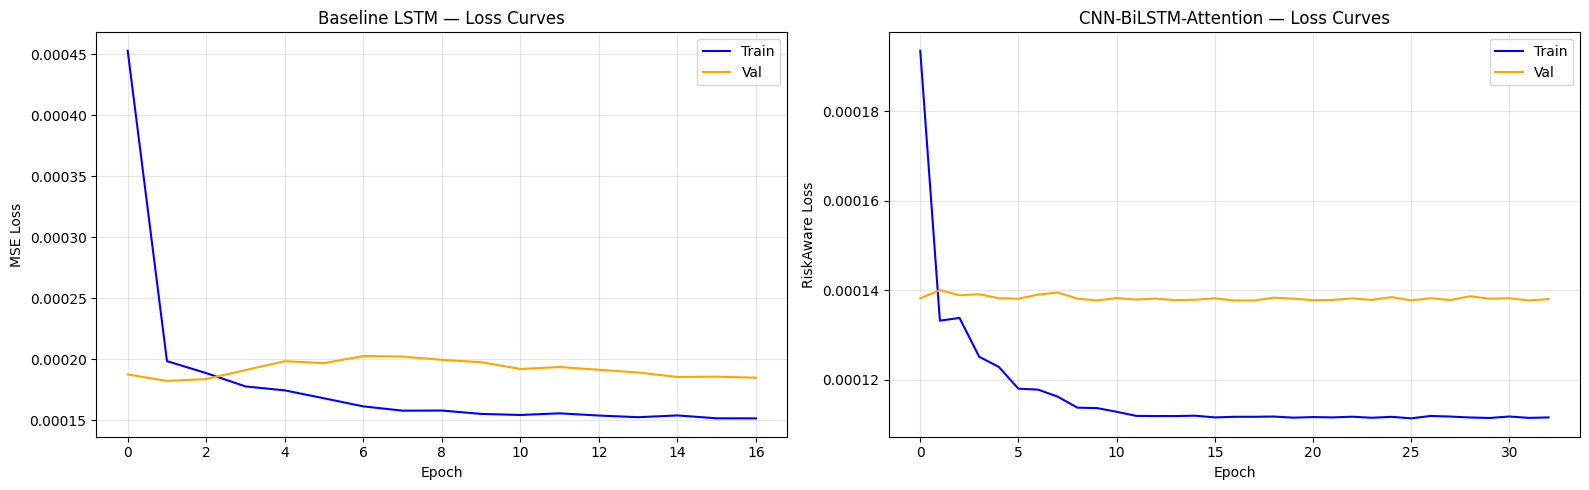

In [ ]:
# Plot 1: Training Curves Side by Side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(bl_train_loss, label='Train', color='blue')
axes[0].plot(bl_val_loss,   label='Val',   color='orange')
axes[0].set_title('Baseline LSTM — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(pm_train_loss, label='Train', color='blue')
axes[1].plot(pm_val_loss,   label='Val',   color='orange')
axes[1].set_title('CNN-BiLSTM-Attention — Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RiskAware Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

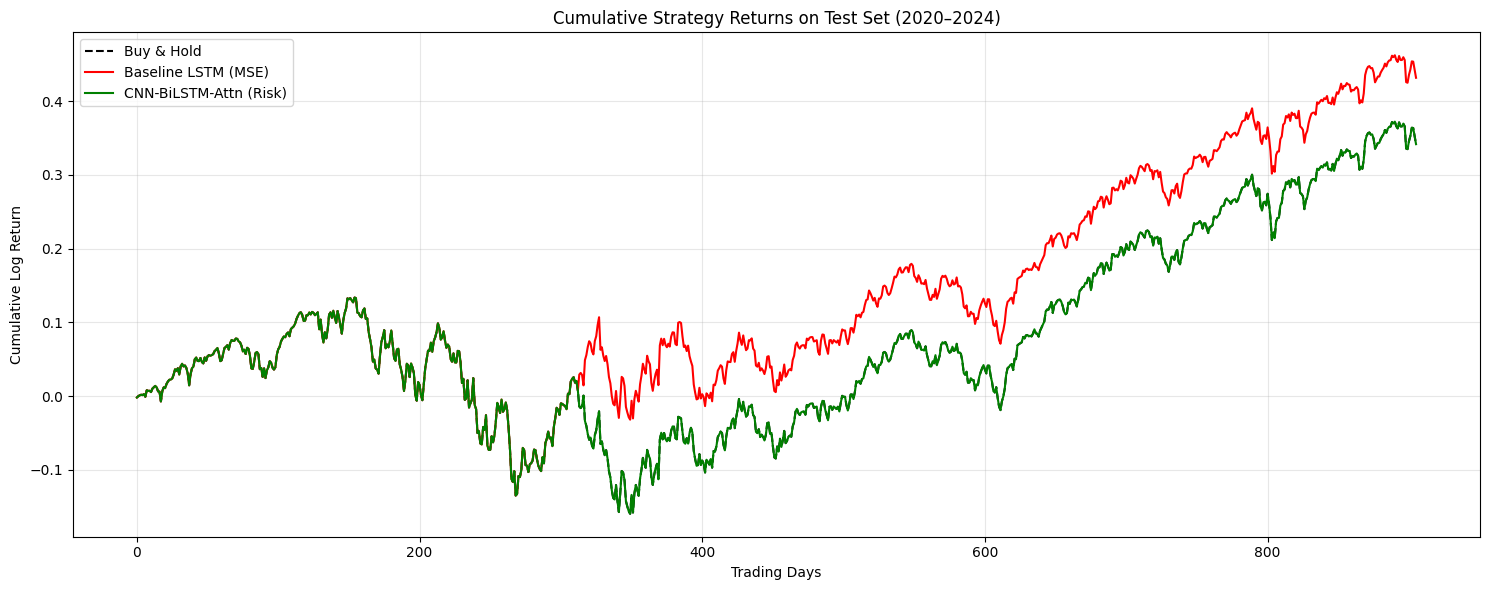

In [ ]:
# Plot 2: Cumulative Returns — Both Strategies vs Buy & Hold
buy_hold = np.cumsum(pm_results['actuals'])   # same actuals for both
bl_cum   = np.cumsum(bl_results['strategy_ret'])
pm_cum   = np.cumsum(pm_results['strategy_ret'])

plt.figure(figsize=(15, 6))
plt.plot(buy_hold, label='Buy & Hold',              color='black',  linewidth=1.5, linestyle='--')
plt.plot(bl_cum,   label='Baseline LSTM (MSE)',     color='red',    linewidth=1.5)
plt.plot(pm_cum,   label='CNN-BiLSTM-Attn (Risk)',  color='green',  linewidth=1.5)
plt.title('Cumulative Strategy Returns on Test Set (2020–2024)')
plt.xlabel('Trading Days')
plt.ylabel('Cumulative Log Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

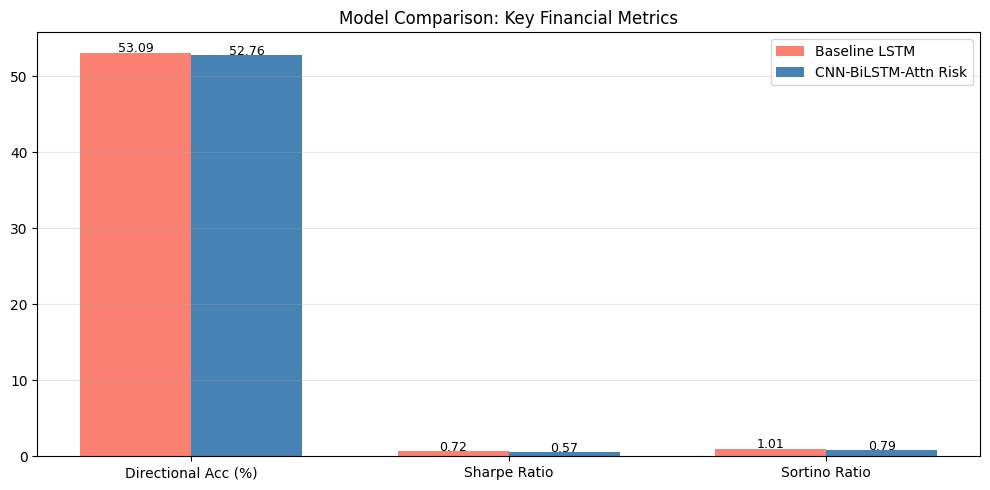

In [ ]:
# Plot 3: Metric Bar Charts
metrics  = ['Dir_Acc', 'Sharpe', 'Sortino']
labels   = ['Directional Acc (%)', 'Sharpe Ratio', 'Sortino Ratio']
bl_vals  = [bl_results[m] for m in metrics]
pm_vals  = [pm_results[m] for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, bl_vals, width, label='Baseline LSTM',        color='salmon')
ax.bar(x + width/2, pm_vals, width, label='CNN-BiLSTM-Attn Risk', color='steelblue')

for i, (b, p) in enumerate(zip(bl_vals, pm_vals)):
    ax.text(i - width/2, b + 0.02, f'{b:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Model Comparison: Key Financial Metrics')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

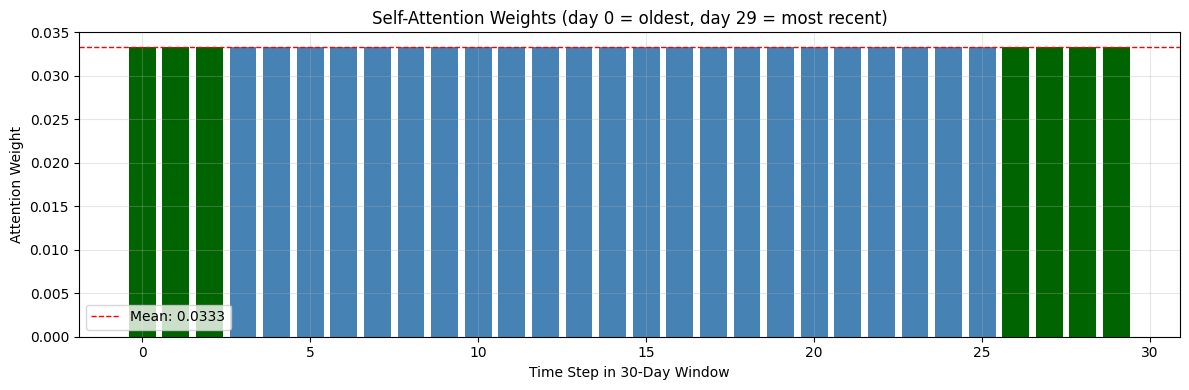

Top 3 attended days: [29  0 28] (higher = model found these days most influential)


In [ ]:
# Plot 4: Attention Weights (Proposed Model)
proposed_model.eval()
with torch.no_grad():
    _, attn_w = proposed_model(X_te_t[:1].to(device))

attn = attn_w.squeeze().cpu().numpy()

plt.figure(figsize=(12, 4))
colors = ['darkgreen' if a > attn.mean() else 'steelblue' for a in attn]
plt.bar(range(WINDOW), attn, color=colors)
plt.axhline(attn.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {attn.mean():.4f}')
plt.title('Self-Attention Weights (day 0 = oldest, day 29 = most recent)')
plt.xlabel('Time Step in 30-Day Window')
plt.ylabel('Attention Weight')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

top3 = np.argsort(attn)[-3:][::-1]
print(f'Top 3 attended days: {top3} (higher = model found these days most influential)')

In [ ]:
#Final Comparison Table
print('\n' + '═'*65)
print(f'{"METRIC":<25} {"Baseline LSTM":>18} {"CNN-BiLSTM-Attn":>18}')
print('═'*65)

metric_rows = [
    ('RMSE',               'RMSE',    False),   # lower is better
    ('MAE',                'MAE',     False),
    ('Directional Acc (%)', 'Dir_Acc', True),    # higher is better
    ('Sharpe Ratio',       'Sharpe',  True),
    ('Sortino Ratio',      'Sortino', True),
    ('Max Drawdown (%)',   'Max_DD',  True),     # less negative is better
]

for label, key, higher_better in metric_rows:
    bl_v = bl_results[key]
    pm_v = pm_results[key]
    if higher_better:
        winner = '← PROPOSED' if pm_v > bl_v else '← BASELINE'
    else:
        winner = '← PROPOSED' if pm_v < bl_v else '← BASELINE'
    print(f'{label:<25} {bl_v:>18} {pm_v:>18}   {winner}')

print('═'*65)
print('\n*Directional Accuracy target: >55% | Sharpe improvement target: +0.3')


═════════════════════════════════════════════════════════════════
METRIC                         Baseline LSTM    CNN-BiLSTM-Attn
═════════════════════════════════════════════════════════════════
RMSE                                0.010568           0.010517   ← PROPOSED
MAE                                  0.00773           0.007713   ← PROPOSED
Directional Acc (%)                    53.09              52.76   ← BASELINE
Sharpe Ratio                          0.7202             0.5697   ← BASELINE
Sortino Ratio                         1.0124             0.7893   ← BASELINE
Max Drawdown (%)          -26.860000610351562 -29.34000015258789   ← BASELINE
═════════════════════════════════════════════════════════════════

*Directional Accuracy target: >55% | Sharpe improvement target: +0.3
